# DTI data preparation

In this notebook, we will:
- Load diffusion MRI (DTI) data
- Understand its structure
- Visualize volumes
- Degrade the data (noise + resolution)
- Prepare it for AI-based denoising

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import re
from functions import *
from tqdm import tqdm

In [23]:
def _next_dataset_version_dir(output_root, prefix="dataset_v"):
    """
    Find next available dataset version directory: dataset_v1, dataset_v2, ...
    """
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    version_re = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    versions = []

    for p in output_root.iterdir():
        if p.is_dir():
            m = version_re.match(p.name)
            if m:
                versions.append(int(m.group(1)))

    next_version = max(versions, default=0) + 1
    target_dir = output_root / f"{prefix}{next_version}"
    target_dir.mkdir(parents=True, exist_ok=False)
    return target_dir


def extract_dwi_files(root_dir, output_root=None, move=False, extensions=None):
    """
    Recursively find all folders named 'dwi' under root_dir and copy/move their files
    into a new dataset_vX folder.

    Args:
        root_dir (str | Path): Root directory to search.
        output_root (str | Path | None): Where dataset_vX should be created.
            Defaults to root_dir.
        move (bool): If True, files are moved instead of copied.
        extensions (set[str] | None): Optional filter, e.g. {".nii.gz", ".bval", ".bvec"}.
            If None, all files from dwi folders are collected.

    Returns:
        dict: Summary with target folder and file counts.
    """
    root = Path(root_dir).resolve()
    out_root = Path(output_root).resolve() if output_root else root
    target_dir = _next_dataset_version_dir(out_root, prefix="dataset_v")

    dwi_dirs = [p for p in root.rglob("*") if p.is_dir() and p.name.lower() == "dwi"]

    def _matches_ext(path_obj):
        if extensions is None:
            return True
        name = path_obj.name.lower()
        # Handle .nii.gz correctly
        if name.endswith(".nii.gz") and ".nii.gz" in {e.lower() for e in extensions}:
            return True
        return any(name.endswith(e.lower()) for e in extensions)

    copied = 0
    skipped = 0

    for dwi_dir in dwi_dirs:
        for src in dwi_dir.rglob("*"):
            if not src.is_file():
                continue
            if not _matches_ext(src):
                skipped += 1
                continue

            # Create collision-safe flattened name from relative path
            rel_name = src.relative_to(root).as_posix().replace("/", "__")
            dst = target_dir / rel_name

            if move:
                shutil.move(str(src), str(dst))
            else:
                shutil.copy2(src, dst)
            copied += 1

    return {
        "target_dir": str(target_dir),
        "dwi_dirs_found": len(dwi_dirs),
        "files_collected": copied,
        "files_skipped": skipped,
        "mode": "move" if move else "copy",
    }


In [41]:
summary = extract_dwi_files(
    root_dir="dataset/pretext_data_1",
    output_root="dataset",
    move=False,
    extensions={".nii.gz", ".bval", ".bvec", ".json"}
)
print(summary)



{'target_dir': '/Users/jannis/PycharmProjects/DW_THI_Project/dataset/dataset_v2', 'dwi_dirs_found': 135, 'files_collected': 544, 'files_skipped': 0, 'mode': 'copy'}


In [42]:
'Choose directory'

data_dir = "dataset/dataset_v2"

entries = find_dwi_datasets(data_dir)
print(f"Found {len(entries)} datasets")

Found 136 datasets


In [43]:
'Load the first dataset and print basic info'

sample = load_dwi_dataset(entries[0])

data = sample["data"]
bvals = sample["bvals"]
bvecs = sample["bvecs"]

print(f"Data shape: {data.shape}")
print(f"b-values: {bvals.shape[0]}")
print(f"b-vectors: {bvecs.shape}")

Data shape: (112, 112, 50, 136)
b-values: 136
b-vectors: (3, 136)


/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  


**Data structure**

The data has shape: (X, Y, Z, N)
- X, Y, Z → spatial dimensions
- N → diffusion volumes (+ b0 images)

There are 130 b-values (N)
- Tells us how strong the diffusion gradient was for each volume
- b ≈ 0 → no diffusion weighting → “b0 image”
- b = 1000 s/mm² → diffusion-weighted image

There are 130 b-vectors
- Each b-vector tells us the direction of the diffusion gradient
- Every entry has three values, corresponding to the [gx, gy, gz] decomposition of the vector

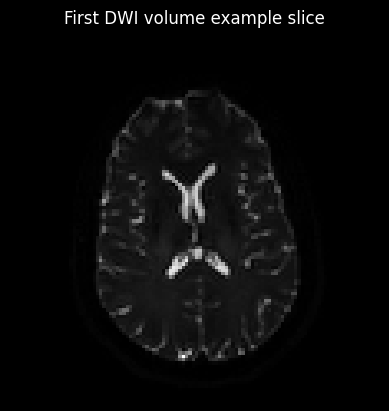

In [44]:
'Example of showing an example slice of the first DWI volume'

plt.imshow(np.rot90(data[:, :, 23, 0], 1), cmap="gray")
plt.title("First DWI volume example slice")
plt.axis("off")
plt.show()

Number of volumes: 136
b0 images: 8
dwi images: 128


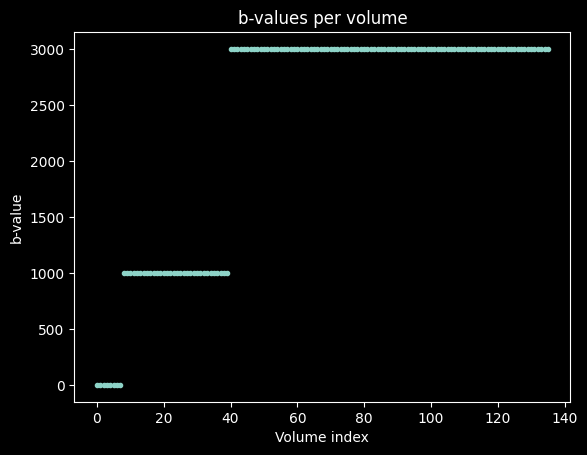

In [45]:
'Split b0 and dwi volumes'

b0, dwi = split_b0_dwi(data, bvals)
print("Number of volumes:", data.shape[-1])
print("b0 images:", b0.shape[-1])
print("dwi images:", dwi.shape[-1])

# plot b-values
plt.plot(bvals, '.')
plt.title("b-values per volume")
plt.xlabel("Volume index")
plt.ylabel("b-value")
plt.show()

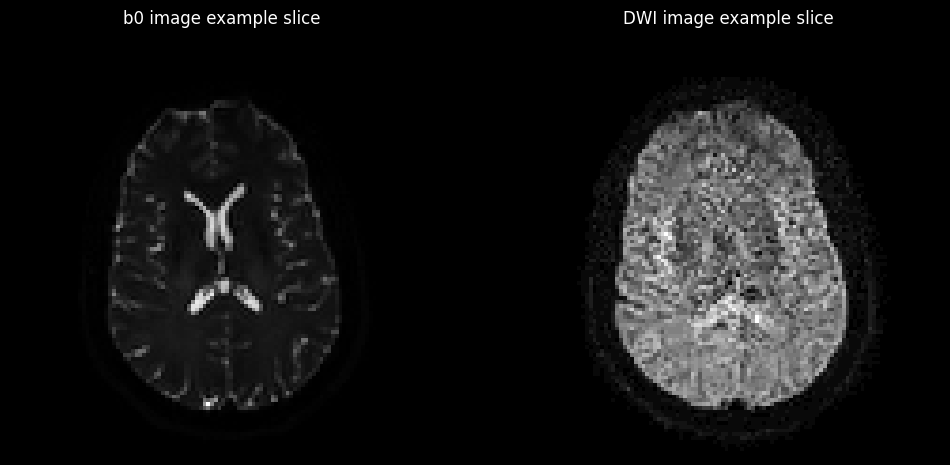

In [46]:
'Show example slices of b0 and DWI volumes'

plt.figure(figsize=(12, 9))
plt.subplot(1, 2, 1)
plt.imshow(np.rot90(b0[..., 0][:, :, 23], 1), cmap="gray")
plt.title("b0 image example slice")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(np.rot90(dwi[..., 0][:, :, 23], 1), cmap="gray")
plt.title("DWI image example slice")
plt.axis("off")
plt.show()

In [47]:
'Example of degrading the DWI data with noise and downsampling'

degraded = lowres_noise(data, noise_max=0.1, keep_fraction=0.6)

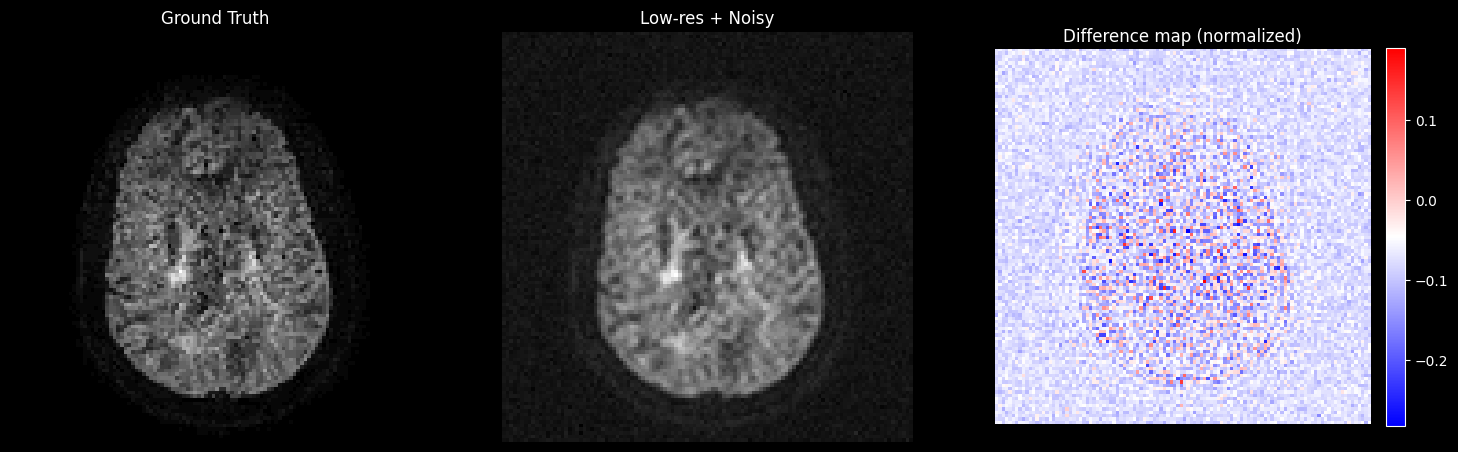

In [48]:
'Visualize example slice and timepoint from both datasets (+ difference map)'

z = 23
b = 10

gt_slice = (data[:, :, z, b] - np.min(data[:, :, z, b])) / (np.max(data[:, :, z, b]) - np.min(data[:, :, z, b]))
deg_slice = (degraded[:, :, z, b] - np.min(degraded[:, :, z, b])) / (np.max(degraded[:, :, z, b]) - np.min(degraded[:, :, z, b]))

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.rot90(deg_slice, 1), cmap="gray")
plt.title("Low-res + Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.rot90(gt_slice - deg_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.show()

In [49]:
'Load all datasets and prepare ML dataset with degraded inputs and clean targets'

dataset = load_all_dwi(data_dir)

print(f"Loaded {len(dataset)} subjects")

/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  
/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  
/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  
/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  
/Users/jannis/PycharmProjects/DW_THI_Project/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  
/Users/jannis/PycharmProjects/DW_TH

KeyboardInterrupt: 

In [33]:
'Prepare ML dataset with degraded inputs and clean targets'
ml_data = []

for sample in tqdm(dataset):
    clean_dwi = sample["data"]
    gtab = sample["gtab"]

    degraded_dwi = lowres_noise(clean_dwi, noise_max=0.1, keep_fraction=0.6)
    
    tensor_clean = compute_dti(clean_dwi, gtab)
    tensor_clean_6d = tensor_to_6d(tensor_clean)
    
    ml_data.append({
        "input": degraded_dwi,
        "target": tensor_clean_6d,
        "bvals": sample["bvals"],
        "bvecs": sample["bvecs"]
    })

print(f"Prepared ML dataset with {len(ml_data)} samples")

Prepared ML dataset with 18 samples


In [34]:
'Save prepared dataset for ML training'

np.savez_compressed("dti_ml_dataset.npz", ml_data=ml_data)

# Extras

Here you have a few extra visualization tools to show the specific effects that noise and resolution have on the images

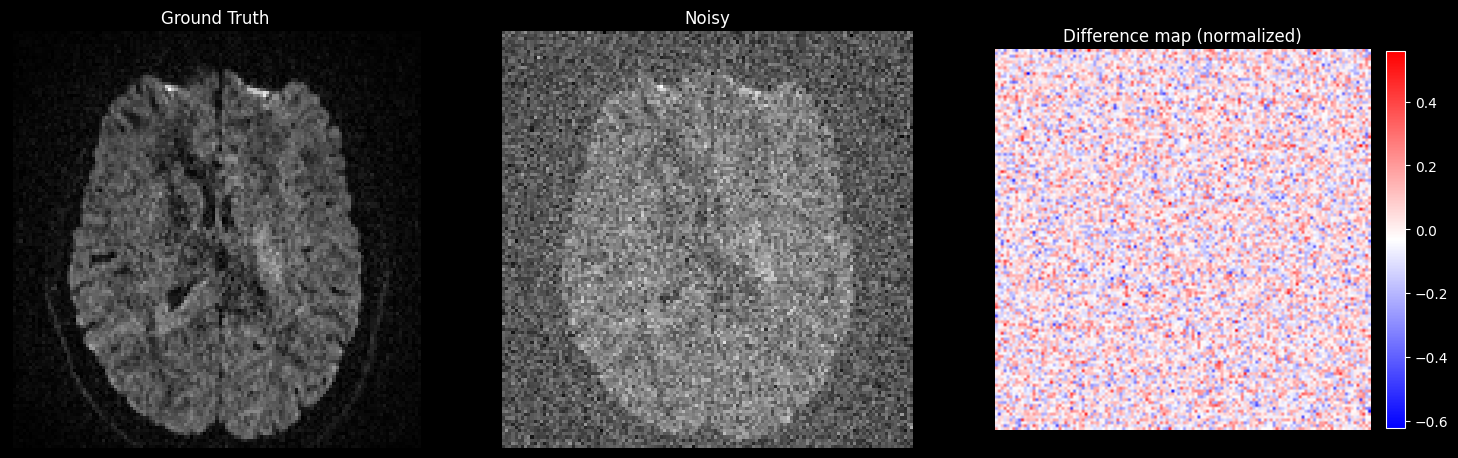

In [35]:
'Visualize noise-only differences'

z = 23
b = 10

gt_slice = data[:, :, z, b]
gt_slice = (gt_slice - np.min(gt_slice)) / (np.max(gt_slice) - np.min(gt_slice))

noise_slice = add_noise(gt_slice, 0.15)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.rot90(noise_slice, 1), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.rot90(gt_slice - noise_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.show()

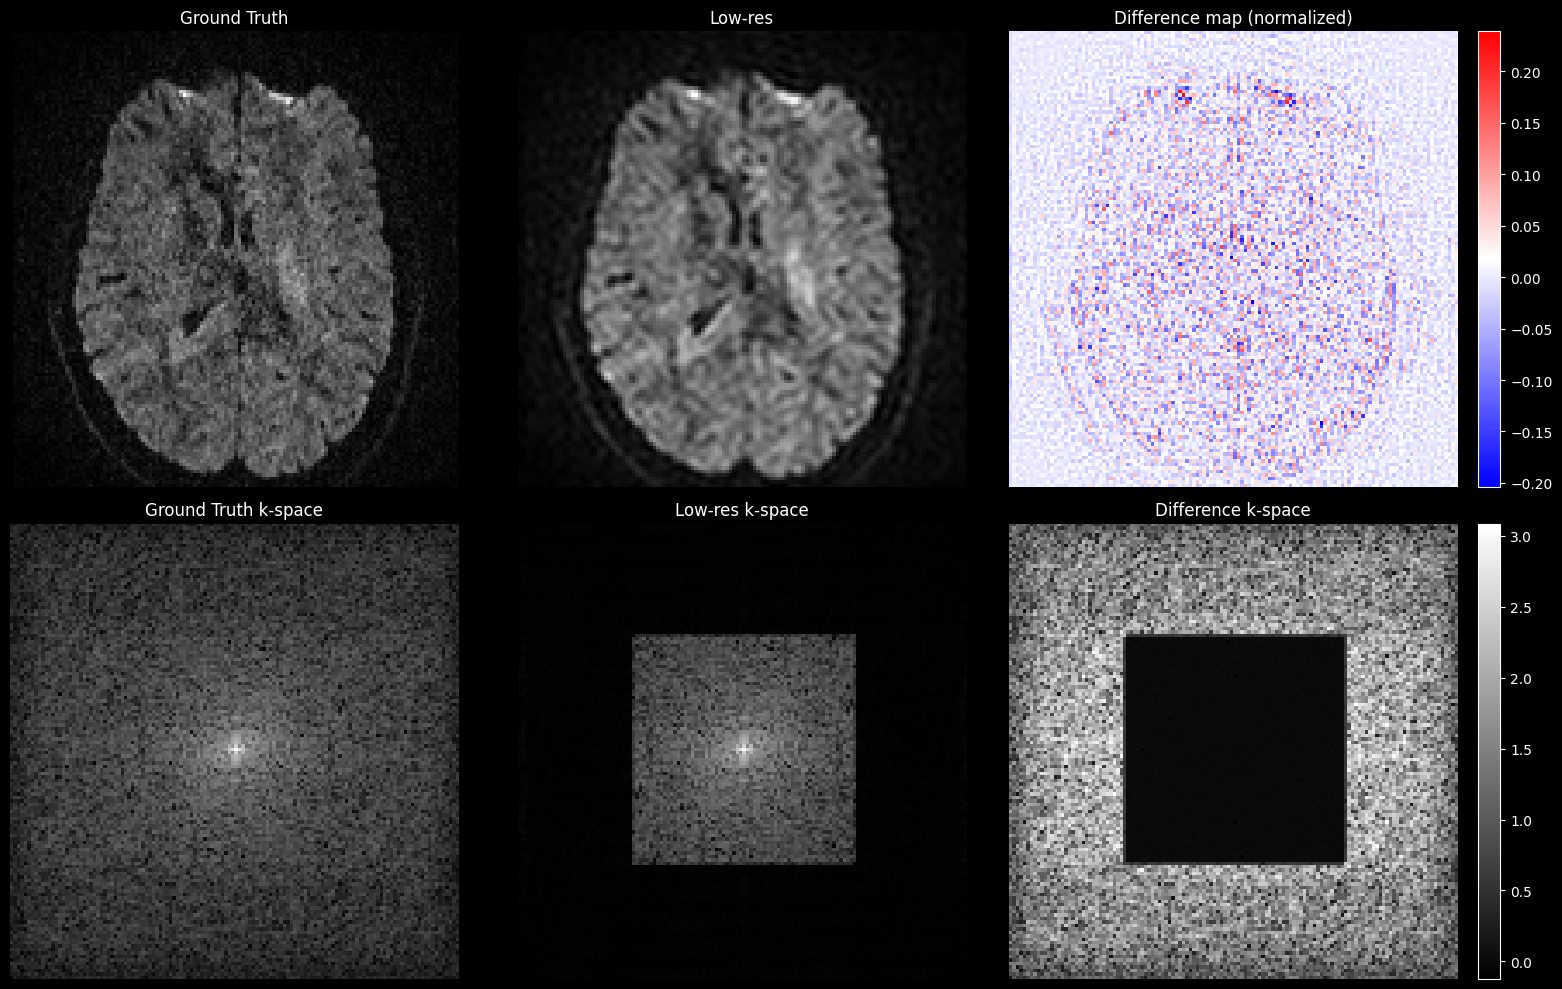

In [36]:
'Visualize resolution-only differences'

lowres_slice = apply_kspace_mask(gt_slice, keep_fraction=0.5)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(np.rot90(lowres_slice, 1), cmap="gray")
plt.title("Low-res")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.rot90(gt_slice - lowres_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 4)
plt.imshow(np.rot90(show_kspace(gt_slice), 1), cmap="gray")
plt.title("Ground Truth k-space")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.rot90(show_kspace(lowres_slice), 1), cmap="gray")
plt.title("Low-res k-space")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.rot90(show_kspace(gt_slice) - show_kspace(lowres_slice), 1), cmap="gray")
plt.title("Difference k-space")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

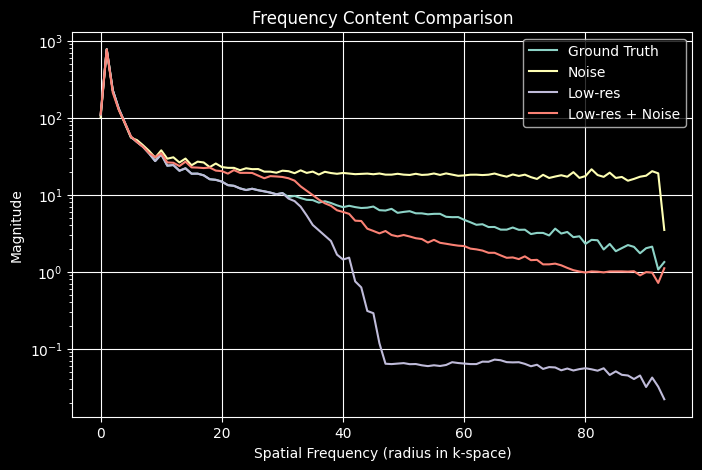

In [37]:
'Visualize changes in frequency distribution for different degradation effects'

gt_profile = radial_profile(gt_slice)
noise_profile = radial_profile(noise_slice)
lowres_profile = radial_profile(lowres_slice)
deg_slice = apply_kspace_mask(add_noise(gt_slice, noise_level=0.15), keep_fraction=0.5)
deg_profile = radial_profile(deg_slice)

plt.figure(figsize=(8,5))

plt.plot(gt_profile, label="Ground Truth")
plt.plot(noise_profile, label="Noise")
plt.plot(lowres_profile, label="Low-res")
plt.plot(deg_profile, label="Low-res + Noise")

plt.xlabel("Spatial Frequency (radius in k-space)")
plt.ylabel("Magnitude")
plt.title("Frequency Content Comparison")

plt.yscale("log")

plt.legend()
plt.grid(True)
plt.show()

Frequency effects of resolution and noise

- Ground Truth: Contains a natural balance of low and high spatial frequencies.

- Low Resolution (k-space truncation): Removes high frequencies → loss of fine details (blurring).

- Noise: Adds energy across all frequencies, especially at high frequencies → elevated baseline.

- Low Resolution + Noise: High frequencies are both reduced (by truncation) and increased (by noise), partially compensating each other and producing a spectrum that can resemble the ground truth.

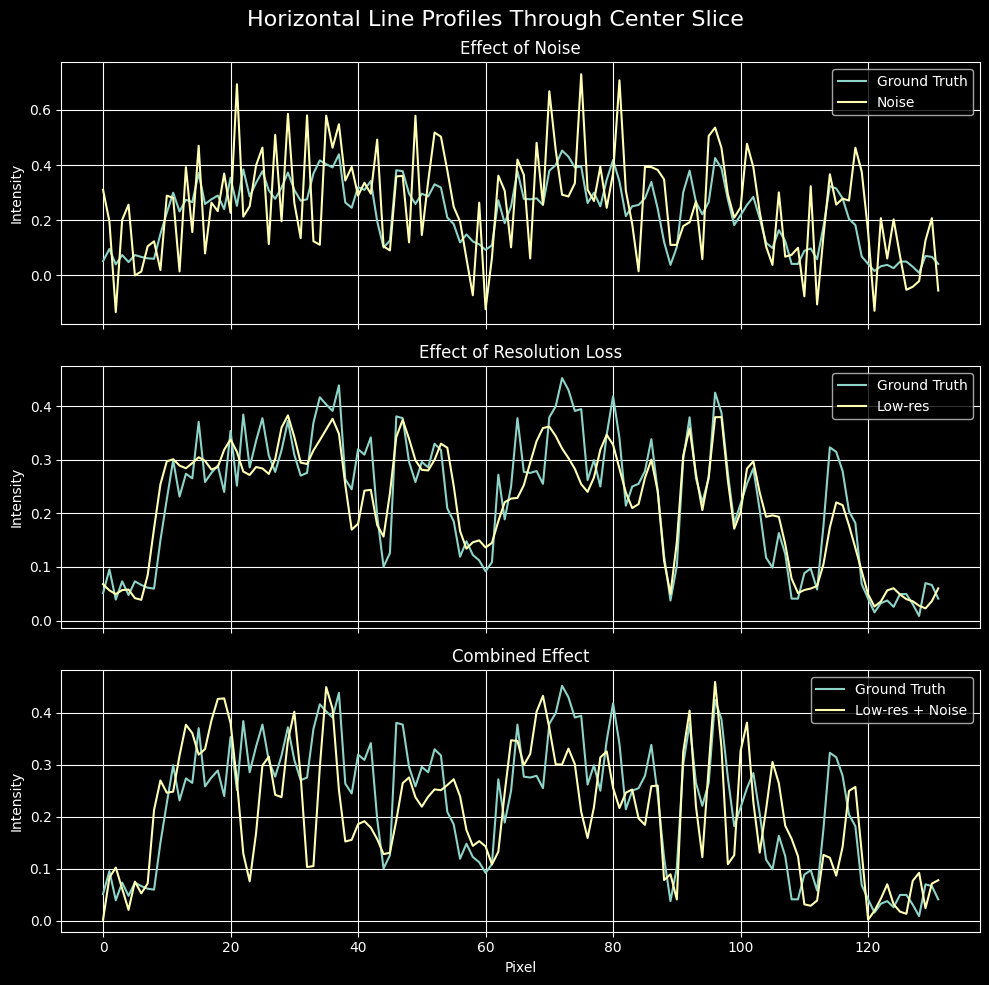

In [38]:
'Visualize profile of horizontal line through center'
y = gt_slice.shape[0] // 2

gt_line = gt_slice[y, :]
noise_line = noise_slice[y, :]
lowres_line = lowres_slice[y, :]
deg_line = deg_slice[y, :]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(gt_line, label="Ground Truth")
axes[0].plot(noise_line, label="Noise")
axes[0].set_title("Effect of Noise")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(gt_line, label="Ground Truth")
axes[1].plot(lowres_line, label="Low-res")
axes[1].set_title("Effect of Resolution Loss")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(gt_line, label="Ground Truth")
axes[2].plot(deg_line, label="Low-res + Noise")
axes[2].set_title("Combined Effect")
axes[2].legend()
axes[2].grid(True)

axes[2].set_xlabel("Pixel")
for ax in axes:
    ax.set_ylabel("Intensity")

fig.suptitle("Horizontal Line Profiles Through Center Slice", fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
'Generate DTI metrics for clean and degraded data'

sample = ml_data[0]

tensor6 = sample["target"]

mask, _ = brain_mask(np.mean(dwi, axis=-1))

fa = compute_fa_from_tensor6(tensor6) * mask
md = compute_md_from_tensor6(tensor6) * mask
color_fa = compute_color_fa_from_tensor6(tensor6) * mask[..., None]

example = dataset[0]
dwi = example["data"]
example_gtab = example["gtab"]
degraded_example = lowres_noise(dwi, noise_max=0.15, keep_fraction=0.6)
tensor6_degraded = tensor_to_6d(compute_dti(degraded_example, example_gtab))

fa_degraded = compute_fa_from_tensor6(tensor6_degraded) * mask
md_degraded = compute_md_from_tensor6(tensor6_degraded) * mask
color_fa_degraded = compute_color_fa_from_tensor6(tensor6_degraded) * mask[..., None]

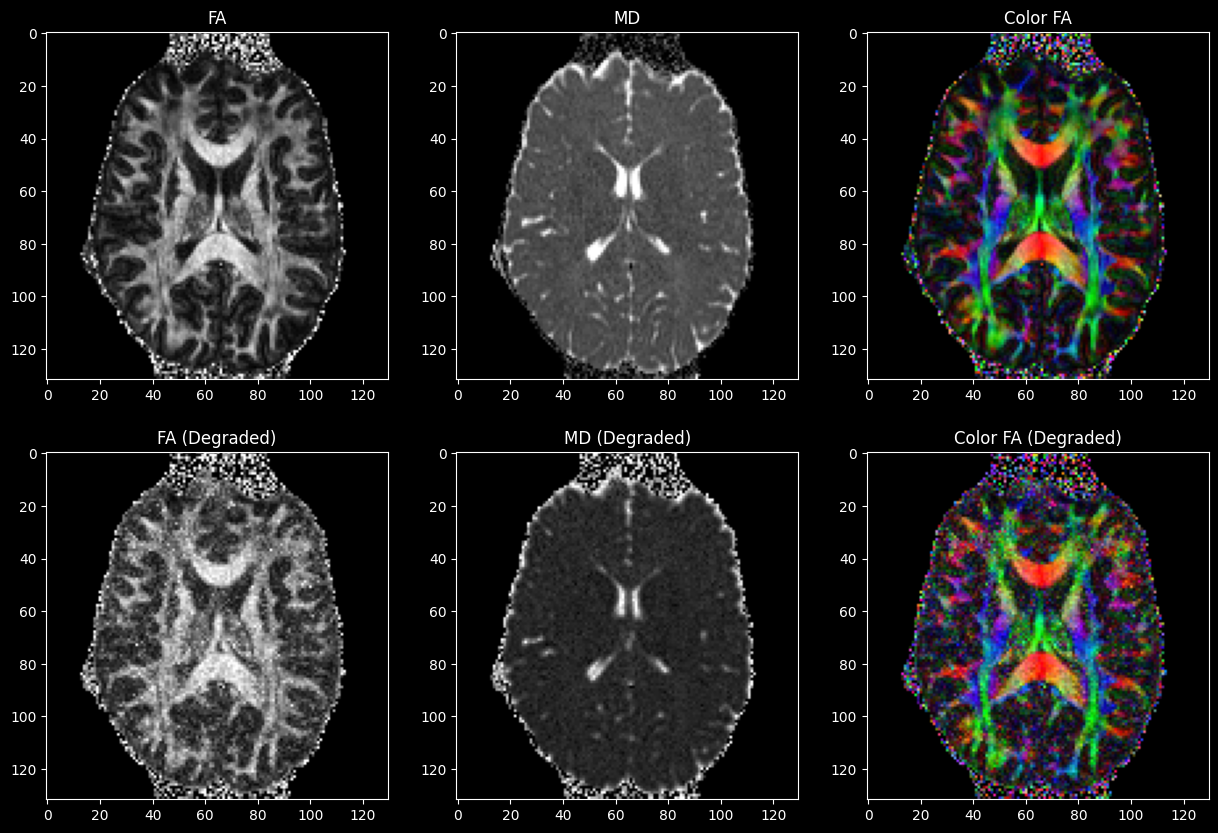

In [40]:
'Visualize DTI metrics for clean and degraded data'

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0,0].imshow(norm(np.rot90(fa[:, :, 23], 1)), cmap="gray")
axes[0,0].set_title("FA")
axes[0,1].imshow(norm(np.rot90(md[:, :, 23], 1)), cmap="gray")
axes[0,1].set_title("MD")
axes[0,2].imshow(norm(np.rot90(color_fa[:, :, 23], 1)), cmap="gray")
axes[0,2].set_title("Color FA")
axes[1,0].imshow(norm(np.rot90(fa_degraded[:, :, 23], 1)), cmap="gray")
axes[1,0].set_title("FA (Degraded)")
axes[1,1].imshow(norm(np.rot90(md_degraded[:, :, 23], 1)), cmap="gray")
axes[1,1].set_title("MD (Degraded)")
axes[1,2].imshow(norm(np.rot90(color_fa_degraded[:, :, 23], 1)), cmap="gray")
axes[1,2].set_title("Color FA (Degraded)")
plt.show()
